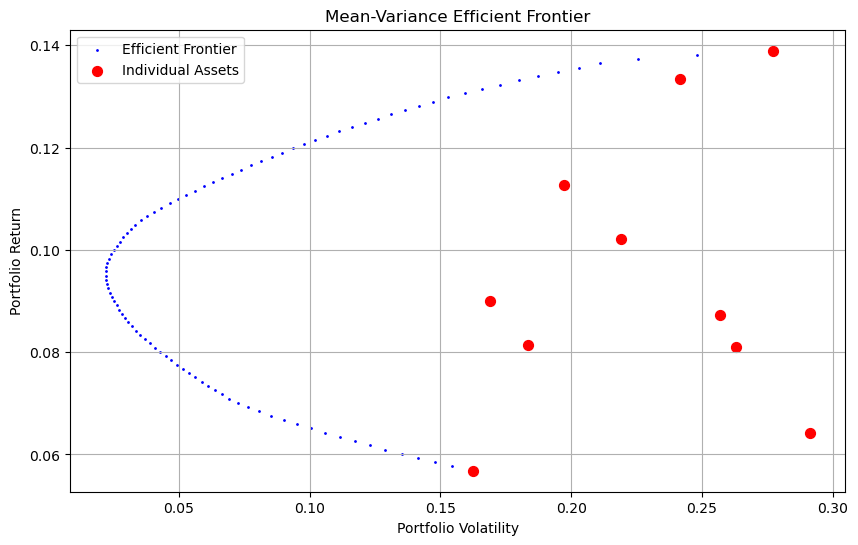

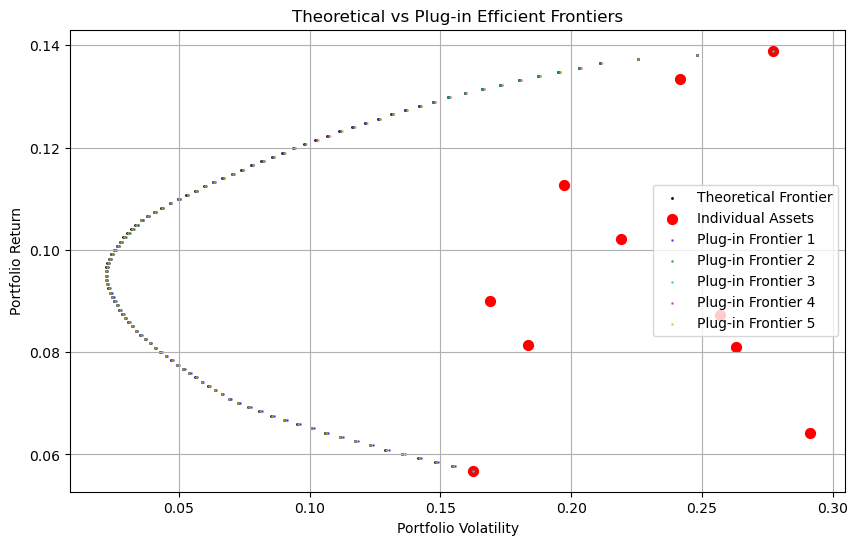

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Set random seed for reproducibility
np.random.seed(42000)

# Number of assets
n_assets = 10

# Generate random expected returns (mean vector)
mu = np.random.normal(0.10, 0.05, n_assets)  # Mean returns around 10% with 5% std

# Generate random covariance matrix
# First create a random correlation matrix
temp = np.random.randn(n_assets, n_assets)
temp = np.dot(temp, temp.T)
# Convert to correlation matrix
corr = temp / np.sqrt(np.outer(np.diag(temp), np.diag(temp)))
# Generate random volatilities between 15% and 35%
vols = np.random.uniform(0.15, 0.35, n_assets)
# Create covariance matrix
Sigma = np.outer(vols, vols) * corr

# Function to calculate portfolio return and volatility
def portfolio_performance(weights):
    returns = np.sum(weights * mu)
    volatility = np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))
    return returns, volatility

# Function for optimization (minimize volatility)
def minimize_volatility(target_return):
    def objective(weights):
        return np.sqrt(np.dot(weights.T, np.dot(Sigma, weights)))
    
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # weights sum to 1
        {'type': 'eq', 'fun': lambda w: np.sum(w * mu) - target_return}  # target return constraint
    ]
    bounds = tuple((0, 1) for _ in range(n_assets))  # weights between 0 and 1
    
    initial_weights = np.array([1/n_assets] * n_assets)
    result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.fun, result.x

# Calculate efficient frontier
target_returns = np.linspace(np.min(mu), np.max(mu), 100)
volatilities = []
for target in target_returns:
    try:
        vol, _ = minimize_volatility(target)
        volatilities.append(vol)
    except:
        continue

# Plot efficient frontier
plt.figure(figsize=(10, 6))
plt.scatter(volatilities, target_returns, c='b', s=1, label='Efficient Frontier')
plt.scatter(np.sqrt(np.diag(Sigma)), mu, c='r', marker='o', s=50, label='Individual Assets')
plt.xlabel('Portfolio Volatility')
plt.ylabel('Portfolio Return')
plt.title('Mean-Variance Efficient Frontier')
plt.grid(True)
plt.legend()
plt.show()



# Simulate portfolio returns and estimate parameters
plt.figure(figsize=(10, 6))

# Plot theoretical frontier first
plt.scatter(volatilities, target_returns, c='k', s=1, label='Theoretical Frontier')
plt.scatter(np.sqrt(np.diag(Sigma)), mu, c='r', marker='o', s=50, label='Individual Assets')

# Colors for different simulations
colors = ['b', 'g', 'c', 'm', 'y']

# Run 5 simulations
for sim in range(5):
    # Simulate individual asset returns using multivariate normal distribution
    n_periods = 252  # One year of daily data
    asset_returns = np.random.multivariate_normal(mu, Sigma, size=n_periods)
    
    # Estimate parameters from simulated asset returns
    est_mu = np.mean(asset_returns, axis=0)
    est_sigma = np.cov(asset_returns.T)
    
    # Calculate plug-in efficient frontier using estimated parameters
    target_returns_sim = np.linspace(np.min(mu), np.max(mu), 100)
    volatilities_sim = []
    
    for target in target_returns_sim:
        try:
            def objective(weights):
                return np.sqrt(np.dot(weights.T, np.dot(est_sigma, weights)))
            
            constraints = [
                {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                {'type': 'eq', 'fun': lambda w: np.sum(w * mu) - target}
            ]
            bounds = tuple((0, 1) for _ in range(n_assets))
            
            initial_weights = np.array([1/n_assets] * n_assets)
            result = minimize(objective, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
            volatilities_sim.append(np.sqrt(np.dot(result.x.T, np.dot(Sigma, result.x))))
        except:
            continue
    
    plt.scatter(volatilities_sim, target_returns_sim, c=colors[sim], s=1, alpha=0.5,
               label=f'Plug-in Frontier {sim+1}')

plt.xlabel('Portfolio Volatility')
plt.ylabel('Portfolio Return')
plt.title('Theoretical vs Plug-in Efficient Frontiers')
plt.grid(True)
plt.legend()
plt.show()

